In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub


/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/minmax_scaler.pkl
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/custom.css
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb56_confusion_matrix.png
/kaggle/input/note

In [2]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================
# LOAD TRAIN / TEST DATA
# ============================================

split_path = (
    "/kaggle/input/notebooks/hafsaferdousi5/"
    "01-data-preprocessing/outputs/splits/train_test.pkl"
)

X_train, X_test, y_train, y_test = joblib.load(split_path)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (5055991, 77)
X_test shape : (1263998, 77)
y_train shape: (5055991,)
y_test shape : (1263998,)


In [4]:
# ============================================
# LOAD TRAIN / TEST DATA
# ============================================

split_path = (
    "/kaggle/input/notebooks/hafsaferdousi5/"
    "01-data-preprocessing/outputs/splits/train_test.pkl"
)

X_train, X_test, y_train, y_test = joblib.load(split_path)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (5055991, 77)
X_test shape : (1263998, 77)
y_train shape: (5055991,)
y_test shape : (1263998,)


In [5]:
# ============================================
# LOAD LABEL ENCODER
# ============================================

le = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/"
    "01-data-preprocessing/outputs/models/label_encoder.pkl"
)

print("Classes:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Classes:
0 -> Benign
1 -> Bot
2 -> Brute Force -Web
3 -> Brute Force -XSS
4 -> DDOS attack-HOIC
5 -> DDOS attack-LOIC-UDP
6 -> DDoS attacks-LOIC-HTTP
7 -> DoS attacks-GoldenEye
8 -> DoS attacks-Hulk
9 -> DoS attacks-SlowHTTPTest
10 -> DoS attacks-Slowloris
11 -> FTP-BruteForce
12 -> Infilteration
13 -> SQL Injection
14 -> SSH-Bruteforce


In [6]:
# ============================================
# LOAD LABEL ENCODER
# ============================================

le = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/"
    "01-data-preprocessing/outputs/models/label_encoder.pkl"
)

print("Classes:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Classes:
0 -> Benign
1 -> Bot
2 -> Brute Force -Web
3 -> Brute Force -XSS
4 -> DDOS attack-HOIC
5 -> DDOS attack-LOIC-UDP
6 -> DDoS attacks-LOIC-HTTP
7 -> DoS attacks-GoldenEye
8 -> DoS attacks-Hulk
9 -> DoS attacks-SlowHTTPTest
10 -> DoS attacks-Slowloris
11 -> FTP-BruteForce
12 -> Infilteration
13 -> SQL Injection
14 -> SSH-Bruteforce


In [7]:
# ============================================
# LOAD ORIGINAL 77 FEATURE NAMES
# ============================================

feature_names = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/"
    "3-feature-selection/outputs/features/feature_names.pkl"
)

feature_names = list(feature_names)

print("Total original features:", len(feature_names))
print(feature_names)

Total original features: 77
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', '

In [8]:
# ============================================
# LOAD CORRELATION-REDUCED FEATURES
# ============================================

correlation_path = (
    "/kaggle/input/notebooks/hafsaferdousi5/"
    "feature-seletion-c/outputs/feature_selection/"
    "correlation/correlation_reduced_features.pkl"
)

correlation_features = joblib.load(correlation_path)

print("Object type:", type(correlation_features))

Object type: <class 'list'>


In [9]:
# ============================================
# HANDLE DIFFERENT PKL FORMATS
# ============================================

if isinstance(correlation_features, pd.DataFrame):

    if "Feature" in correlation_features.columns:
        correlation_features = (
            correlation_features["Feature"].tolist()
        )

    elif "feature" in correlation_features.columns:
        correlation_features = (
            correlation_features["feature"].tolist()
        )

    else:
        correlation_features = correlation_features.iloc[:, 0].tolist()

elif isinstance(correlation_features, np.ndarray):

    correlation_features = correlation_features.tolist()

elif isinstance(correlation_features, tuple):

    correlation_features = list(correlation_features)

elif not isinstance(correlation_features, list):

    correlation_features = list(correlation_features)

print("Correlation-selected features:", len(correlation_features))
print(correlation_features)

Correlation-selected features: 56
['Protocol', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Bwd Header Length', 'Fwd Header Length', 'Flow IAT Mean', 'Idle Max', 'Fwd Packets Length Total', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 

In [10]:
# ============================================
# VALIDATE FEATURES
# ============================================

missing_features = [
    f for f in correlation_features
    if f not in feature_names
]

if missing_features:
    print("ERROR: These features are missing:")
    print(missing_features)
    raise ValueError("Correlation feature names do not match original feature names.")

print("All correlation features exist in original feature list.")
print("Number of features:", len(correlation_features))

All correlation features exist in original feature list.
Number of features: 56


In [11]:
# ============================================
# VALIDATE FEATURES
# ============================================

missing_features = [
    f for f in correlation_features
    if f not in feature_names
]

if missing_features:
    print("ERROR: These features are missing:")
    print(missing_features)
    raise ValueError("Correlation feature names do not match original feature names.")

print("All correlation features exist in original feature list.")
print("Number of features:", len(correlation_features))

All correlation features exist in original feature list.
Number of features: 56


In [12]:
# ============================================
# GET COLUMN INDICES
# ============================================

feature_indices = [
    feature_names.index(feature)
    for feature in correlation_features
]

print("Number of selected indices:", len(feature_indices))

Number of selected indices: 56


In [13]:
# ============================================
# REDUCE TRAIN / TEST TO 56 FEATURES
# ============================================

X_train_corr = X_train[:, feature_indices]
X_test_corr = X_test[:, feature_indices]

print("Original X_train:", X_train.shape)
print("Correlation X_train:", X_train_corr.shape)

print("Original X_test:", X_test.shape)
print("Correlation X_test:", X_test_corr.shape)

Original X_train: (5055991, 77)
Correlation X_train: (5055991, 56)
Original X_test: (1263998, 77)
Correlation X_test: (1263998, 56)


In [14]:
# ============================================
# BORUTA SAMPLING PLAN
# ============================================

sampling_plan = {
    "Benign": 15000,
    "DDoS attacks-LOIC-HTTP": 5000,
    "DDOS attack-HOIC": 5000,
    "DoS attacks-Hulk": 5000,
    "Bot": 5000,
    "Infilteration": 5000,
    "SSH-Bruteforce": 5000,

    "DoS attacks-GoldenEye": 5000,
    "DoS attacks-Slowloris": 5000,
    "DDOS attack-LOIC-UDP": None,
    "Brute Force -Web": None,
    "Brute Force -XSS": None,
    "SQL Injection": None,
    "DoS attacks-SlowHTTPTest": None,
    "FTP-BruteForce": None
}

print("Sampling plan loaded.")

Sampling plan loaded.


In [15]:
# ============================================
# CLASS NAME -> ENCODED LABEL
# ============================================

class_to_id = {
    class_name: idx
    for idx, class_name in enumerate(le.classes_)
}

print(class_to_id)

{'Benign': 0, 'Bot': 1, 'Brute Force -Web': 2, 'Brute Force -XSS': 3, 'DDOS attack-HOIC': 4, 'DDOS attack-LOIC-UDP': 5, 'DDoS attacks-LOIC-HTTP': 6, 'DoS attacks-GoldenEye': 7, 'DoS attacks-Hulk': 8, 'DoS attacks-SlowHTTPTest': 9, 'DoS attacks-Slowloris': 10, 'FTP-BruteForce': 11, 'Infilteration': 12, 'SQL Injection': 13, 'SSH-Bruteforce': 14}


In [16]:
# ============================================
# CREATE BORUTA SAMPLE
# ============================================

rng = np.random.default_rng(RANDOM_STATE)

sample_indices = []

for class_name, requested_size in sampling_plan.items():

    if class_name not in class_to_id:
        print("WARNING - class not found:", class_name)
        continue

    class_id = class_to_id[class_name]

    # Indices belonging to this class
    class_indices = np.where(y_train == class_id)[0]

    available = len(class_indices)

    # None = use all available samples
    if requested_size is None:
        n_samples = available
    else:
        n_samples = min(requested_size, available)

    selected = rng.choice(
        class_indices,
        size=n_samples,
        replace=False
    )

    sample_indices.extend(selected)

    print(
        f"{class_name:35s} "
        f"available={available:8d} "
        f"selected={n_samples:8d}"
    )

sample_indices = np.array(sample_indices)

# Shuffle
rng.shuffle(sample_indices)

print("\nTotal Boruta samples:", len(sample_indices))

Benign                              available= 3995317 selected=   15000
DDoS attacks-LOIC-HTTP              available=  460291 selected=    5000
DDOS attack-HOIC                    available=  159089 selected=    5000
DoS attacks-Hulk                    available=  116159 selected=    5000
Bot                                 available=  115628 selected=    5000
Infilteration                       available=   91055 selected=    5000
SSH-Bruteforce                      available=   75238 selected=    5000
DoS attacks-GoldenEye               available=   33125 selected=    5000
DoS attacks-Slowloris               available=    7926 selected=    5000
DDOS attack-LOIC-UDP                available=    1384 selected=    1384
Brute Force -Web                    available=     442 selected=     442
Brute Force -XSS                    available=     183 selected=     183
SQL Injection                       available=      67 selected=      67
DoS attacks-SlowHTTPTest            available=     

In [17]:
!pip install -q boruta

In [18]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

print("Boruta imported successfully.")

Boruta imported successfully.


In [19]:
# ============================================
# BORUTA RANDOM FOREST ESTIMATOR
# ============================================

rf_boruta = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Boruta Random Forest ready.")

Boruta Random Forest ready.


In [20]:
# ============================================
# CREATE BORUTA DATA FROM 56 CORRELATION FEATURES
# ============================================

import numpy as np


feature_indices = [
    feature_names.index(f)
    for f in correlation_features
]

# 77 -> 56 features
X_train_corr = X_train[:, feature_indices]
X_test_corr = X_test[:, feature_indices]

print("Original:", X_train.shape)
print("After Correlation:", X_train_corr.shape)

Original: (5055991, 77)
After Correlation: (5055991, 56)


In [21]:
# ============================================
# CREATE BORUTA SAMPLE - FINAL
# ============================================

import numpy as np

RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

sample_indices = []

for class_name, sample_size in sampling_plan.items():

    # Check class
    if class_name not in class_to_id:
        print(f"WARNING: {class_name} not found")
        continue

    class_id = class_to_id[class_name]

    # Get indices for this class
    class_indices = np.where(y_train == class_id)[0]

    available = len(class_indices)

    # None = take all available samples
    if sample_size is None:
        n_samples = available
    else:
        n_samples = min(sample_size, available)

    # Random sampling
    selected = rng.choice(
        class_indices,
        size=n_samples,
        replace=False
    )

    sample_indices.extend(selected)

    print(
        f"{class_name:35s} "
        f"available={available:8d} "
        f"selected={n_samples:8d}"
    )

# Convert to numpy
sample_indices = np.array(sample_indices)

# Shuffle
rng.shuffle(sample_indices)

# ============================================
# CREATE BORUTA DATA
# ============================================

# Convert y_train to NumPy array
y_train_np = np.asarray(y_train).ravel()

# Create Boruta dataset
X_boruta = X_train_corr[sample_indices]
y_boruta = y_train_np[sample_indices]

print("X_boruta shape:", X_boruta.shape)
print("y_boruta shape:", y_boruta.shape)

print("\n============================================")
print("BORUTA DATA READY")
print("============================================")
print("X_boruta shape:", X_boruta.shape)
print("y_boruta shape:", y_boruta.shape)
print("Number of features:", X_boruta.shape[1])
print("Number of samples:", X_boruta.shape[0])

Benign                              available= 3995317 selected=   15000
DDoS attacks-LOIC-HTTP              available=  460291 selected=    5000
DDOS attack-HOIC                    available=  159089 selected=    5000
DoS attacks-Hulk                    available=  116159 selected=    5000
Bot                                 available=  115628 selected=    5000
Infilteration                       available=   91055 selected=    5000
SSH-Bruteforce                      available=   75238 selected=    5000
DoS attacks-GoldenEye               available=   33125 selected=    5000
DoS attacks-Slowloris               available=    7926 selected=    5000
DDOS attack-LOIC-UDP                available=    1384 selected=    1384
Brute Force -Web                    available=     442 selected=     442
Brute Force -XSS                    available=     183 selected=     183
SQL Injection                       available=      67 selected=      67
DoS attacks-SlowHTTPTest            available=     

In [22]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

print("Boruta imported successfully.")

Boruta imported successfully.


In [23]:
# BORUTA RANDOM FOREST ESTIMATOR
# ============================================

rf_boruta = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Boruta Random Forest ready.")

Boruta Random Forest ready.


In [24]:
# ============================================
# BORUTA FEATURE SELECTION
# ============================================

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators="auto",
    max_iter=30,
    random_state=42,
    verbose=2
)

boruta.fit(
    X_boruta,
    y_boruta
)

print("Boruta completed successfully.")

Iteration: 	1 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	2 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	3 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	4 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	5 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	6 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	7 / 30
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	8 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	9 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	10 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	11 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	12 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	13 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	14 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	15 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteration: 	16 / 30
Confirmed: 	34
Tentative: 	4
Rejected: 	18
Iteratio

In [25]:
# ============================================
# BORUTA RESULTS
# ============================================

selected_mask = boruta.support_
tentative_mask = boruta.support_weak_

selected_features = [
    correlation_features[i]
    for i in range(len(correlation_features))
    if selected_mask[i]
]

tentative_features = [
    correlation_features[i]
    for i in range(len(correlation_features))
    if tentative_mask[i]
]

rejected_features = [
    correlation_features[i]
    for i in range(len(correlation_features))
    if not selected_mask[i] and not tentative_mask[i]
]

print("============================================")
print("BORUTA RESULTS")
print("============================================")

print("Original correlation features :", len(correlation_features))
print("Selected features             :", len(selected_features))
print("Tentative features            :", len(tentative_features))
print("Rejected features             :", len(rejected_features))

print("\nSelected Features:")
for i, feature in enumerate(selected_features, 1):
    print(i, feature)

BORUTA RESULTS
Original correlation features : 56
Selected features             : 36
Tentative features            : 1
Rejected features             : 19

Selected Features:
1 Fwd Packet Length Max
2 Fwd Packet Length Std
3 Bwd Packet Length Max
4 Bwd Packet Length Std
5 Flow Bytes/s
6 Flow Packets/s
7 Flow IAT Std
8 Fwd IAT Std
9 Bwd IAT Total
10 Bwd IAT Mean
11 Bwd IAT Std
12 Bwd IAT Max
13 Bwd IAT Min
14 Fwd Packets/s
15 Bwd Packets/s
16 Packet Length Min
17 Packet Length Max
18 Packet Length Std
19 Packet Length Variance
20 PSH Flag Count
21 ACK Flag Count
22 Down/Up Ratio
23 Init Fwd Win Bytes
24 Init Bwd Win Bytes
25 Fwd Seg Size Min
26 Bwd Header Length
27 Fwd Header Length
28 Flow IAT Mean
29 Idle Max
30 Fwd Packets Length Total
31 Avg Bwd Segment Size
32 Avg Fwd Segment Size
33 RST Flag Count
34 Flow Duration
35 Packet Length Mean
36 Flow IAT Max


In [26]:
import pandas as pd

# ============================================
# BORUTA RESULT TABLE
# ============================================

boruta_results = pd.DataFrame({
    "Feature": correlation_features,
    "Boruta_Rank": boruta.ranking_,
    "Boruta_Support": boruta.support_,
    "Boruta_Tentative": boruta.support_weak_
})

# Keep ONLY confirmed Boruta features
boruta_selected_results = boruta_results[
    boruta_results["Boruta_Support"] == True
].copy()

# Sort by Boruta rank, then feature name
boruta_selected_results = boruta_selected_results.sort_values(
    by=["Boruta_Rank", "Feature"]
)

# Display exactly like your example
print(
    boruta_selected_results.to_string(index=True)
)

print("\nTotal Selected Features:", len(boruta_selected_results))

                     Feature  Boruta_Rank  Boruta_Support  Boruta_Tentative
26            ACK Flag Count            1            True             False
48      Avg Bwd Segment Size            1            True             False
49      Avg Fwd Segment Size            1            True             False
43         Bwd Header Length            1            True             False
14               Bwd IAT Max            1            True             False
12              Bwd IAT Mean            1            True             False
15               Bwd IAT Min            1            True             False
13               Bwd IAT Std            1            True             False
11             Bwd IAT Total            1            True             False
4      Bwd Packet Length Max            1            True             False
6      Bwd Packet Length Std            1            True             False
19             Bwd Packets/s            1            True             False
28          

In [27]:
selected_features = boruta_selected_results["Feature"].tolist()

print("Selected features:", len(selected_features))
print(selected_features)

Selected features: 36
['ACK Flag Count', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Bwd Header Length', 'Bwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Total', 'Bwd Packet Length Max', 'Bwd Packet Length Std', 'Bwd Packets/s', 'Down/Up Ratio', 'Flow Bytes/s', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Std', 'Flow Packets/s', 'Fwd Header Length', 'Fwd IAT Std', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Fwd Packets Length Total', 'Fwd Packets/s', 'Fwd Seg Size Min', 'Idle Max', 'Init Bwd Win Bytes', 'Init Fwd Win Bytes', 'PSH Flag Count', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Min', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count']


In [28]:
# ============================================
# SAVE BORUTA RESULTS
# ============================================

import os
import joblib
import pandas as pd

output_dir = "/kaggle/working/outputs/feature_selection/boruta"

os.makedirs(output_dir, exist_ok=True)

# Selected feature names
joblib.dump(
    selected_features,
    f"{output_dir}/boruta_selected_features.pkl"
)

pd.DataFrame({
    "Feature": selected_features
}).to_csv(
    f"{output_dir}/boruta_selected_features.csv",
    index=False
)

# Tentative features
joblib.dump(
    tentative_features,
    f"{output_dir}/boruta_tentative_features.pkl"
)

pd.DataFrame({
    "Feature": tentative_features
}).to_csv(
    f"{output_dir}/boruta_tentative_features.csv",
    index=False
)

# Rejected features
joblib.dump(
    rejected_features,
    f"{output_dir}/boruta_rejected_features.pkl"
)

pd.DataFrame({
    "Feature": rejected_features
}).to_csv(
    f"{output_dir}/boruta_rejected_features.csv",
    index=False
)

# Boruta object
joblib.dump(
    boruta,
    f"{output_dir}/boruta_model.pkl"
)

print("============================================")
print("Boruta results saved successfully!")
print("============================================")

for root, dirs, files in os.walk(output_dir):
    for file in files:
        print(os.path.join(root, file))

Boruta results saved successfully!
/kaggle/working/outputs/feature_selection/boruta/boruta_rejected_features.pkl
/kaggle/working/outputs/feature_selection/boruta/boruta_model.pkl
/kaggle/working/outputs/feature_selection/boruta/boruta_selected_features.csv
/kaggle/working/outputs/feature_selection/boruta/boruta_tentative_features.pkl
/kaggle/working/outputs/feature_selection/boruta/boruta_rejected_features.csv
/kaggle/working/outputs/feature_selection/boruta/boruta_tentative_features.csv
/kaggle/working/outputs/feature_selection/boruta/boruta_selected_features.pkl


In [29]:
import joblib

joblib.dump(
    selected_features,
    "/kaggle/working/outputs/boruta_selected_features.pkl"
)

['/kaggle/working/outputs/boruta_selected_features.pkl']

In [30]:
# ============================================
# LOAD BORUTA SELECTED 36 FEATURES
# ============================================

import joblib
import numpy as np
import pandas as pd

boruta_features_path = (
    "/kaggle/working/outputs/boruta_selected_features.pkl"
)

selected_features = joblib.load(boruta_features_path)

print("Number of Boruta-selected features:", len(selected_features))
print("\nSelected 36 features:")

for i, feature in enumerate(selected_features, 1):
    print(f"{i:2d}. {feature}")

Number of Boruta-selected features: 36

Selected 36 features:
 1. ACK Flag Count
 2. Avg Bwd Segment Size
 3. Avg Fwd Segment Size
 4. Bwd Header Length
 5. Bwd IAT Max
 6. Bwd IAT Mean
 7. Bwd IAT Min
 8. Bwd IAT Std
 9. Bwd IAT Total
10. Bwd Packet Length Max
11. Bwd Packet Length Std
12. Bwd Packets/s
13. Down/Up Ratio
14. Flow Bytes/s
15. Flow Duration
16. Flow IAT Max
17. Flow IAT Mean
18. Flow IAT Std
19. Flow Packets/s
20. Fwd Header Length
21. Fwd IAT Std
22. Fwd Packet Length Max
23. Fwd Packet Length Std
24. Fwd Packets Length Total
25. Fwd Packets/s
26. Fwd Seg Size Min
27. Idle Max
28. Init Bwd Win Bytes
29. Init Fwd Win Bytes
30. PSH Flag Count
31. Packet Length Max
32. Packet Length Mean
33. Packet Length Min
34. Packet Length Std
35. Packet Length Variance
36. RST Flag Count


In [31]:
# ============================================
# CREATE 36-FEATURE DATASET
# ============================================

selected_indices = [
    feature_names.index(feature)
    for feature in selected_features
]

X_train_36 = X_train[:, selected_indices]
X_test_36  = X_test[:, selected_indices]

print("Original X_train:", X_train.shape)
print("X_train with 36 features:", X_train_36.shape)

print("Original X_test :", X_test.shape)
print("X_test with 36 features :", X_test_36.shape)

Original X_train: (5055991, 77)
X_train with 36 features: (5055991, 36)
Original X_test : (1263998, 77)
X_test with 36 features : (1263998, 36)


In [32]:
# ============================================
# SHAP FEATURE IMPORTANCE
# ============================================

!pip install -q shap xgboost

In [33]:
# ============================================
# STRATIFIED SHAP SAMPLE
# ALL 15 CLASSES INCLUDED
# ============================================

import numpy as np
import pandas as pd
import xgboost as xgb
import shap

RANDOM_STATE = 42
SHAP_SAMPLES_PER_CLASS = 1000

y_train_np = np.asarray(y_train).ravel()

rng = np.random.default_rng(RANDOM_STATE)

shap_indices = []

for class_id in np.unique(y_train_np):

    class_indices = np.where(y_train_np == class_id)[0]

    n_samples = min(
        SHAP_SAMPLES_PER_CLASS,
        len(class_indices)
    )

    selected = rng.choice(
        class_indices,
        size=n_samples,
        replace=False
    )

    shap_indices.extend(selected)

shap_indices = np.array(shap_indices)

rng.shuffle(shap_indices)

X_shap = X_train_36[shap_indices]
y_shap = y_train_np[shap_indices]

print("============================================")
print("STRATIFIED SHAP SAMPLE")
print("============================================")
print("X_shap:", X_shap.shape)
print("y_shap:", y_shap.shape)
print("Classes:", np.unique(y_shap))
print("Number of classes:", len(np.unique(y_shap)))

print("\nClass distribution:")
print(
    pd.Series(y_shap)
    .value_counts()
    .sort_index()
)

STRATIFIED SHAP SAMPLE
X_shap: (10779, 36)
y_shap: (10779,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Number of classes: 15

Class distribution:
0     1000
1     1000
2      442
3      183
4     1000
5     1000
6     1000
7     1000
8     1000
9       44
10    1000
11      43
12    1000
13      67
14    1000
Name: count, dtype: int64


In [34]:
# ============================================
# XGBOOST MODEL FOR SHAP
# ============================================

shap_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    num_class=15,

    eval_metric="mlogloss",
    tree_method="hist",

    random_state=42,
    n_jobs=-1
)

shap_model.fit(
    X_shap,
    y_shap
)

print("XGBoost SHAP model trained successfully.")

XGBoost SHAP model trained successfully.


In [35]:
# ============================================
# SHAP VALUES
# ============================================

explainer = shap.TreeExplainer(shap_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed.")

SHAP calculation completed.


In [36]:
# ============================================
# SHAP GLOBAL IMPORTANCE
# ============================================

if isinstance(shap_values, list):

    shap_array = np.stack(shap_values, axis=0)

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=(0, 1)
    )

else:

    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:

        mean_abs_shap = np.mean(
            np.abs(shap_array),
            axis=(0, 2)
        )

    elif shap_array.ndim == 2:

        mean_abs_shap = np.mean(
            np.abs(shap_array),
            axis=0
        )

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )


# ============================================
# CREATE SHAP RANKING
# ============================================

shap_ranking = pd.DataFrame({
    "Feature": selected_features,
    "Mean_Abs_SHAP": mean_abs_shap
})

shap_ranking = shap_ranking.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

shap_ranking["SHAP_Rank"] = (
    np.arange(len(shap_ranking)) + 1
)

shap_ranking = shap_ranking[
    ["SHAP_Rank", "Feature", "Mean_Abs_SHAP"]
]

print(shap_ranking.to_string(index=False))

 SHAP_Rank                  Feature  Mean_Abs_SHAP
         1         Fwd Seg Size Min       0.841550
         2       Init Fwd Win Bytes       0.709233
         3            Bwd Packets/s       0.357959
         4            Flow Duration       0.353934
         5        Fwd Header Length       0.316765
         6            Flow IAT Mean       0.277419
         7             Flow IAT Max       0.224571
         8            Fwd Packets/s       0.211397
         9        Bwd Header Length       0.197189
        10     Avg Fwd Segment Size       0.183389
        11             Flow Bytes/s       0.181020
        12             Flow IAT Std       0.142114
        13 Fwd Packets Length Total       0.139170
        14              Fwd IAT Std       0.126247
        15    Fwd Packet Length Max       0.120036
        16       Init Bwd Win Bytes       0.116273
        17           Flow Packets/s       0.104164
        18       Packet Length Mean       0.101358
        19    Bwd Packet Length

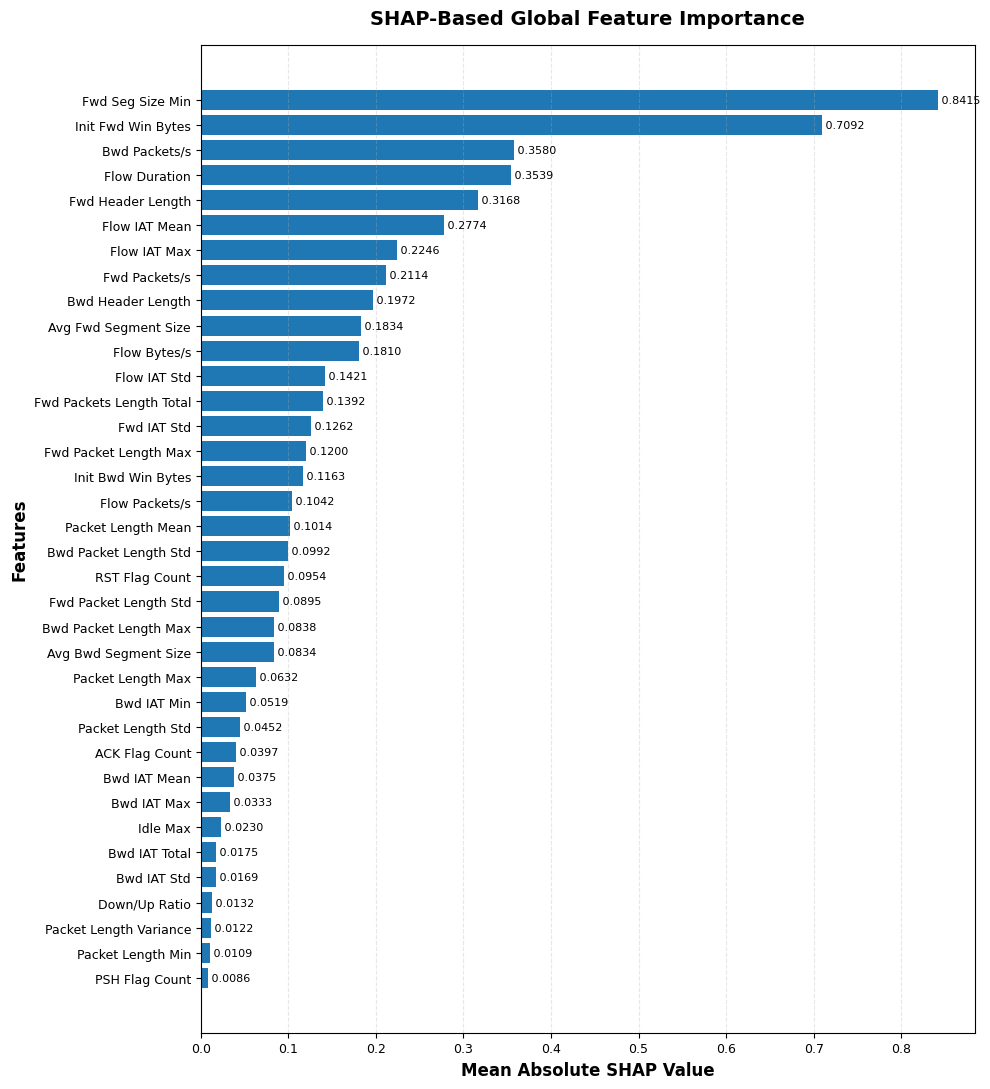

In [37]:
# ============================================
# PROFESSIONAL SHAP FEATURE IMPORTANCE GRAPH
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# Sort from highest to lowest importance
plot_df = shap_ranking.sort_values(
    "Mean_Abs_SHAP",
    ascending=True
).copy()

plt.figure(figsize=(10, 11))

bars = plt.barh(
    plot_df["Feature"],
    plot_df["Mean_Abs_SHAP"]
)

# Add values at end of bars
for bar, value in zip(
    bars,
    plot_df["Mean_Abs_SHAP"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=8
    )

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "SHAP-Based Global Feature Importance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tick_params(
    axis="both",
    labelsize=9
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Save high-resolution figure for IEEE paper
plt.savefig(
    "/kaggle/working/SHAP_Global_Feature_Importance_36.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

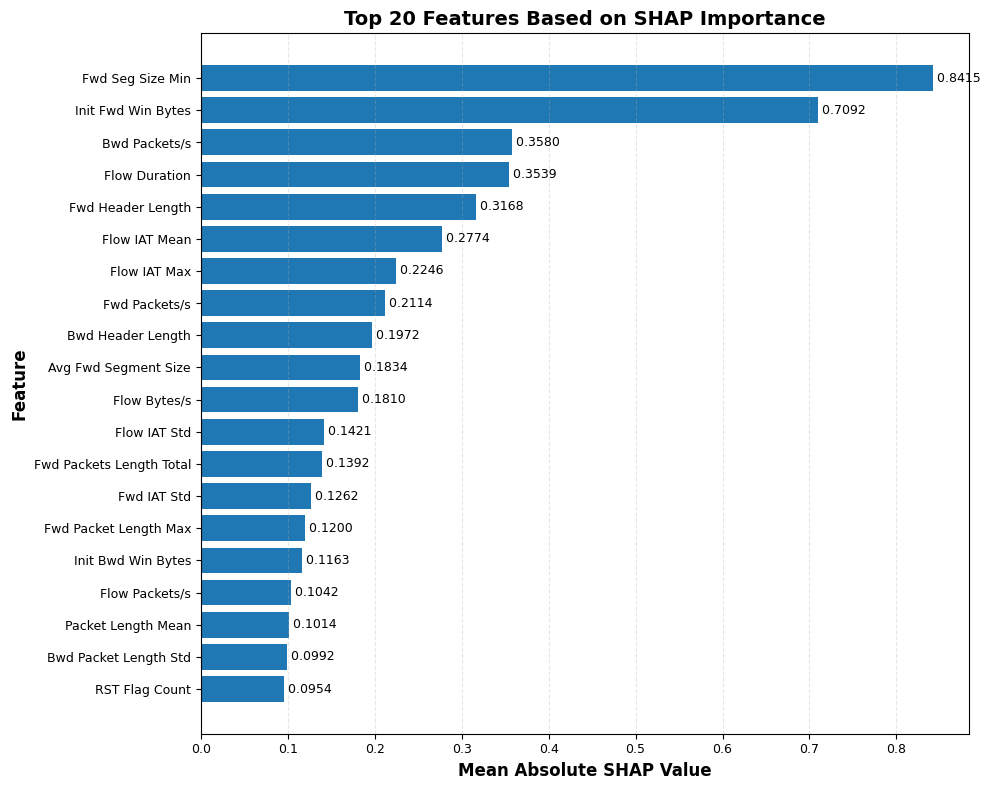

In [38]:
# ============================================
# PROFESSIONAL TOP-20 SHAP FEATURE IMPORTANCE
# ============================================

import matplotlib.pyplot as plt

top20_shap = (
    shap_ranking
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .head(20)
    .sort_values("Mean_Abs_SHAP", ascending=True)
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top20_shap["Feature"],
    top20_shap["Mean_Abs_SHAP"]
)

# Add SHAP values
for bar, value in zip(
    bars,
    top20_shap["Mean_Abs_SHAP"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Feature",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Top 20 Features Based on SHAP Importance",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tick_params(
    axis="both",
    labelsize=9
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/SHAP_Top20_Features.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [39]:
top20_shap = (
    shap_ranking
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .head(20)
)

top20_shap.to_csv(
    "/kaggle/working/SHAP_Top20_Features.csv",
    index=False
)

print(top20_shap.to_string(index=False))

 SHAP_Rank                  Feature  Mean_Abs_SHAP
         1         Fwd Seg Size Min       0.841550
         2       Init Fwd Win Bytes       0.709233
         3            Bwd Packets/s       0.357959
         4            Flow Duration       0.353934
         5        Fwd Header Length       0.316765
         6            Flow IAT Mean       0.277419
         7             Flow IAT Max       0.224571
         8            Fwd Packets/s       0.211397
         9        Bwd Header Length       0.197189
        10     Avg Fwd Segment Size       0.183389
        11             Flow Bytes/s       0.181020
        12             Flow IAT Std       0.142114
        13 Fwd Packets Length Total       0.139170
        14              Fwd IAT Std       0.126247
        15    Fwd Packet Length Max       0.120036
        16       Init Bwd Win Bytes       0.116273
        17           Flow Packets/s       0.104164
        18       Packet Length Mean       0.101358
        19    Bwd Packet Length

In [40]:
# ============================================
# 36 BORUTA-SELECTED FEATURES
# ============================================

import numpy as np
import pandas as pd
import joblib

# Load 36 Boruta-selected feature names
selected_features = joblib.load(
    "/kaggle/working/outputs/boruta_selected_features.pkl"
)

print("Number of selected features:", len(selected_features))

assert len(selected_features) == 36, \
    f"Expected 36 features, got {len(selected_features)}"

# Get original column indices
selected_indices = [
    feature_names.index(f)
    for f in selected_features
]

# Create 36-feature datasets
X_train_36 = X_train[:, selected_indices]
X_test_36  = X_test[:, selected_indices]

y_train_np = np.asarray(y_train).ravel()
y_test_np  = np.asarray(y_test).ravel()

print("\n============================================")
print("36-FEATURE DATASET")
print("============================================")
print("X_train:", X_train_36.shape)
print("X_test :", X_test_36.shape)
print("y_train:", y_train_np.shape)
print("y_test :", y_test_np.shape)
print("Classes:", np.unique(y_train_np))

Number of selected features: 36

36-FEATURE DATASET
X_train: (5055991, 36)
X_test : (1263998, 36)
y_train: (5055991,)
y_test : (1263998,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [41]:
# ============================================
# INSTALL LIBRARIES
# ============================================

!pip install -q xgboost lightgbm catboost

In [42]:
# ============================================
# IMPORT MODELS
# ============================================

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("All four model libraries loaded.")

All four model libraries loaded.


In [43]:
# ============================================
# XGBOOST
# ============================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softmax",
    num_class=15,
    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_36,
    y_train_np
)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [44]:
# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,

    class_weight="balanced",

    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train_36,
    y_train_np
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [45]:
# ============================================
# LIGHTGBM
# ============================================

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,

    num_leaves=31,
    max_depth=-1,

    subsample=0.8,
    colsample_bytree=0.8,

    objective="multiclass",
    num_class=15,

    random_state=42,
    n_jobs=-1,

    verbosity=-1
)

print("Training LightGBM...")

lgb_model.fit(
    X_train_36,
    y_train_np
)

print("LightGBM training completed.")

Training LightGBM...
LightGBM training completed.


In [46]:
# ============================================
# CATBOOST
# ============================================

cat_model = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.1,

    loss_function="MultiClass",

    random_seed=42,

    verbose=100,
    thread_count=-1,

    allow_writing_files=False
)

print("Training CatBoost...")

cat_model.fit(
    X_train_36,
    y_train_np
)

print("CatBoost training completed.")

Training CatBoost...
0:	learn: 1.5072539	total: 23s	remaining: 1h 54m 46s
100:	learn: 0.0723551	total: 38m 7s	remaining: 1h 15m 7s
200:	learn: 0.0675367	total: 1h 15m 54s	remaining: 37m 23s
299:	learn: 0.0658562	total: 1h 53m 11s	remaining: 0us
CatBoost training completed.


In [47]:
# ============================================
# MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

results = []

predictions = {}

for model_name, model in models.items():

    print("\n============================================")
    print(model_name)
    print("============================================")

    y_pred = model.predict(X_test_36)

    y_pred = np.asarray(y_pred).ravel()

    predictions[model_name] = y_pred

    accuracy = accuracy_score(
        y_test_np,
        y_pred
    )

    precision_macro = precision_score(
        y_test_np,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_test_np,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test_np,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test_np,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test_np,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_test_np,
        y_pred
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision_Macro": precision_macro,
        "Recall_Macro": recall_macro,
        "F1_Macro": f1_macro,
        "F1_Weighted": f1_weighted,
        "MCC": mcc,
        "Balanced_Accuracy": balanced_acc
    })

    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Precision (Macro)  : {precision_macro:.4f}")
    print(f"Recall (Macro)     : {recall_macro:.4f}")
    print(f"F1 (Macro)         : {f1_macro:.4f}")
    print(f"F1 (Weighted)      : {f1_weighted:.4f}")
    print(f"MCC                : {mcc:.4f}")
    print(f"Balanced Accuracy  : {balanced_acc:.4f}")


XGBoost
Accuracy           : 0.9819
Precision (Macro)  : 0.8433
Recall (Macro)     : 0.7643
F1 (Macro)         : 0.7833
F1 (Weighted)      : 0.9743
MCC                : 0.9500
Balanced Accuracy  : 0.7643

Random Forest
Accuracy           : 0.8230
Precision (Macro)  : 0.7058
Recall (Macro)     : 0.7969
F1 (Macro)         : 0.7114
F1 (Weighted)      : 0.8849
MCC                : 0.7003
Balanced Accuracy  : 0.7969

LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy           : 0.8340
Precision (Macro)  : 0.2950
Recall (Macro)     : 0.3020
F1 (Macro)         : 0.2863
F1 (Weighted)      : 0.8469
MCC                : 0.5895
Balanced Accuracy  : 0.3020

CatBoost
Accuracy           : 0.9818
Precision (Macro)  : 0.8748
Recall (Macro)     : 0.7537
F1 (Macro)         : 0.7795
F1 (Weighted)      : 0.9738
MCC                : 0.9497
Balanced Accuracy  : 0.7537


In [49]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1_Macro",
    ascending=False
).reset_index(drop=True)

print("\n============================================")
print("MODEL COMPARISON — 36 BORUTA FEATURES")
print("============================================")

display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision_Macro": "{:.4f}",
        "Recall_Macro": "{:.4f}",
        "F1_Macro": "{:.4f}",
        "F1_Weighted": "{:.4f}",
        "MCC": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}"
    })
)


MODEL COMPARISON — 36 BORUTA FEATURES


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted,MCC,Balanced_Accuracy
0,XGBoost,0.9819,0.8433,0.7643,0.7833,0.9743,0.9500,0.7643
1,CatBoost,0.9818,0.8748,0.7537,0.7795,0.9738,0.9497,0.7537
2,Random Forest,0.8230,0.7058,0.7969,0.7114,0.8849,0.7003,0.7969
3,LightGBM,0.8340,0.2950,0.3020,0.2863,0.8469,0.5895,0.3020


In [50]:
# ============================================
# SAVE RESULTS
# ============================================

output_dir = "/kaggle/working/outputs/models_36_features"

import os
os.makedirs(output_dir, exist_ok=True)

results_df.to_csv(
    f"{output_dir}/model_comparison_36_features.csv",
    index=False
)

joblib.dump(
    xgb_model,
    f"{output_dir}/xgboost_36_features.pkl"
)

joblib.dump(
    rf_model,
    f"{output_dir}/random_forest_36_features.pkl"
)

joblib.dump(
    lgb_model,
    f"{output_dir}/lightgbm_36_features.pkl"
)

joblib.dump(
    cat_model,
    f"{output_dir}/catboost_36_features.pkl"
)

print("All models and results saved.")

All models and results saved.


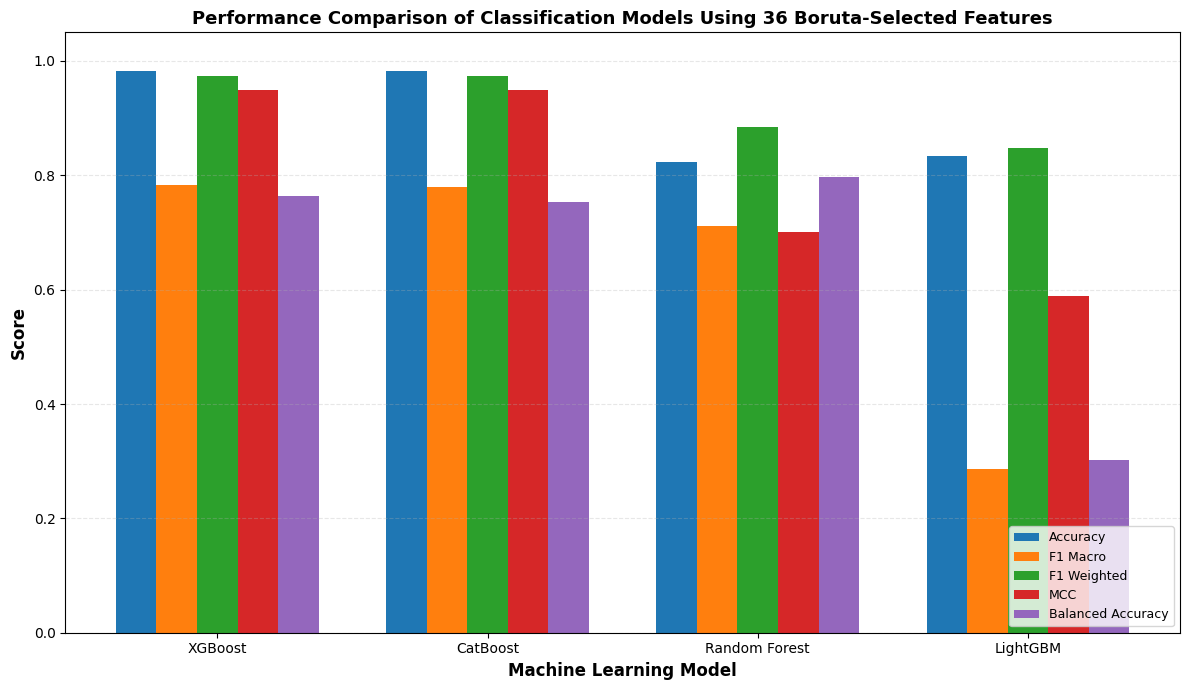

In [51]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

import matplotlib.pyplot as plt

plot_df = results_df.copy()

metrics = [
    "Accuracy",
    "F1_Macro",
    "F1_Weighted",
    "MCC",
    "Balanced_Accuracy"
]

x = np.arange(len(plot_df))
width = 0.15

plt.figure(figsize=(12, 7))

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 2) * width,
        plot_df[metric],
        width,
        label=metric.replace("_", " ")
    )

plt.xticks(
    x,
    plot_df["Model"],
    fontsize=10
)

plt.ylabel(
    "Score",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Performance Comparison of Classification Models Using 36 Boruta-Selected Features",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/model_comparison_36_features.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [52]:
# ============================================
# FINAL MODEL COMPARISON — 36 FEATURES
# Accuracy, Precision, Recall, F1, MCC, AUC
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

results = []

models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

for model_name, model in models.items():

    print(f"Evaluating {model_name}...")

    # Predictions
    y_pred = model.predict(X_test_36)
    y_pred = np.asarray(y_pred).ravel()

    # Probability predictions for AUC
    y_prob = model.predict_proba(X_test_36)

    # ========================================
    # METRICS
    # ========================================

    accuracy = accuracy_score(
        y_test_np,
        y_pred
    )

    precision = precision_score(
        y_test_np,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test_np,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test_np,
        y_pred,
        average="macro",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test_np,
        y_pred
    )

    # Multiclass ROC-AUC
    auc = roc_auc_score(
        y_test_np,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc,
        "AUC": auc
    })


# ============================================
# FINAL DATAFRAME
# ============================================

results_df = pd.DataFrame(results)

# Sort by F1
results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


# ============================================
# DISPLAY
# ============================================

print("\n============================================")
print("MODEL COMPARISON — 36 BORUTA FEATURES")
print("============================================")

display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

Evaluating XGBoost...
Evaluating Random Forest...
Evaluating LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluating CatBoost...

MODEL COMPARISON — 36 BORUTA FEATURES


,Model,Accuracy,Precision,Recall,F1,MCC,AUC
0,XGBoost,0.9819,0.8433,0.7643,0.7833,0.9500,0.9946
1,CatBoost,0.9818,0.8748,0.7537,0.7795,0.9497,0.9932
2,Random Forest,0.8230,0.7058,0.7969,0.7114,0.7003,0.9933
3,LightGBM,0.8340,0.2950,0.3020,0.2863,0.5895,0.6390
